<a href="https://colab.research.google.com/github/pe53127/Simulaci-n-del-PAS/blob/main/Simulacion_PAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación del PAS
Cargamos primero Numpy y matplotlib

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

Recordemos que el paseo aleatorio simple (PAS) es un proceso estocástico, cuyo conjunto de índices es $\mathbb{N}$, que se define de la siguiente manera. Tomamos una sucesión de variables aleatorias $Z_s$ independientes e idénticamente distribuidas tal que $P[Z_s=1]=p$ y $P[Z_s=-1]=1-p$. Entonces, para cada $t \in \mathbb{N}$, definimos $X_t=\sum_{i=1}^t Z_i$.

Con esto dicho, procedamos a hacer el código para la simulación.

In [ ]:
def simular_PAS(p,n,reps):
  # p es la probabilidad de que se suba hacia arriba en la gráfica del PAS. Es un número entre 0 y 1.
  # n es el número de pasos a simular en la trayectoria, es decir, el número de veces que subimos o bajamos en la gráfica del PAS. Es un número natural.
  # reps es el número de trayectorias a simular. Es un número natural.

  # Añadimos comprobaciones para ver si los formatos introducidos son correctos.

  try:
    p=float(p) #Pasamos a número porque se introduce como string.
    if p>=0 and p<=1: #Comprobamos que p es un número entre 0 y 1.
      pass #Se sale del if si las líneas anteriores funcionan.
    else:
      print("El valor de p no es correcto. Debe ser un número entre 0 y 1.")
      return #Salimos de la función de simulación.

  except ValueError: #Por si no se ha introducido un número.
    print("No has introducido un número en p.")
    return #Salimos de la función de simulación.


  try:
    n=int(n) #Pasamos a número porque se introduce como string.
    if n<=0: #Comprobamos que n es natural.
      print("El valor de n no es correcto. Debe ser un número natural.")
      return

  except ValueError: #Por si no se ha introducido un número.
    print("No has introducido un número natural en n.")
    return


  try:
    reps=int(reps) #Pasamos a número porque se introduce como string.
    if reps<=0: #Comprobamos que n es natural
      print("El valor de reps no es correcto. Debe ser un número natural.")
      return

  except ValueError: #Por si no se ha introducido un número.
    print("No has introducido un número natural en reps.")
    return

  #A continuación, generamos todos los pasos a la vez usando random.choice. Elegimos entre 1 y -1 n veces con probabilidades p y 1-p.

  pasos=np.random.choice([1, -1], size=(reps,n), p=[p, 1-p]) #Shape: (reps,n).

  #Tenemos en la variable pasos si debemos de subir o bajar en la gráfica. Ahora, calculamos la trayectoria usando cumsum. Además, añadimos
  #el valor 0 al inicio del vector pasos pues empezamos en el 0.

  trayectoria=np.cumsum(np.insert(pasos,0,0, axis=1), axis=1) #Shape: (reps,n+1).

  return trayectoria

# Visualización 1

Diapositiva 16:

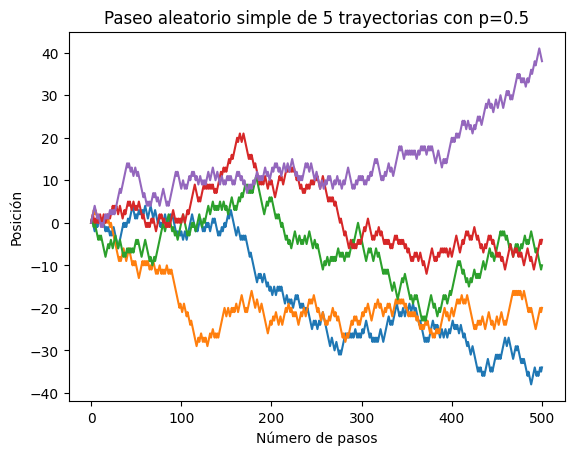

In [ ]:
trayectoria=simular_PAS(0.5,500,5)
for i in range(trayectoria.shape[0]):
  plt.plot(trayectoria[i])

plt.xlabel("Número de pasos")
plt.ylabel("Posición")
plt.title("Paseo aleatorio simple de 5 trayectorias con p=0.5");

Diapositiva 17:

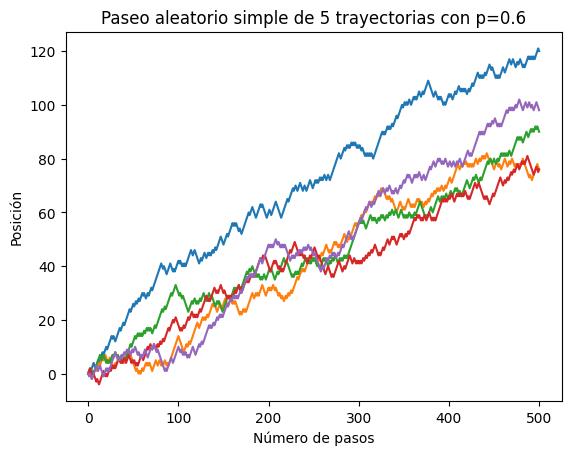

In [ ]:
trayectoria=simular_PAS(0.6,500,5)
for i in range(trayectoria.shape[0]):
  plt.plot(trayectoria[i])

plt.xlabel("Número de pasos")
plt.ylabel("Posición")
plt.title("Paseo aleatorio simple de 5 trayectorias con p=0.6");

Diapositiva 18:

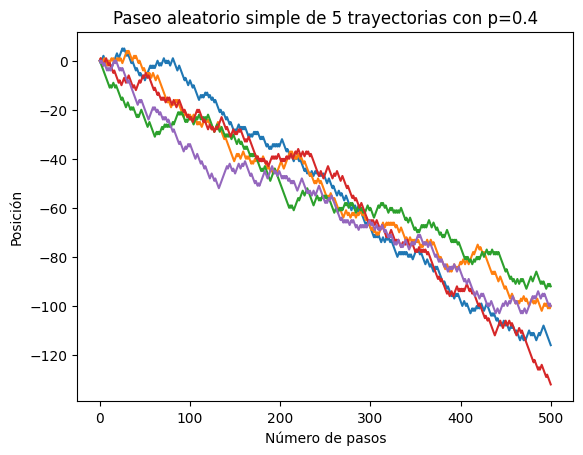

In [ ]:
trayectoria=simular_PAS(0.4,500,5)
for i in range(trayectoria.shape[0]):
  plt.plot(trayectoria[i])

plt.xlabel("Número de pasos")
plt.ylabel("Posición")
plt.title("Paseo aleatorio simple de 5 trayectorias con p=0.4");

# Visualización 2

Diapositiva 30:

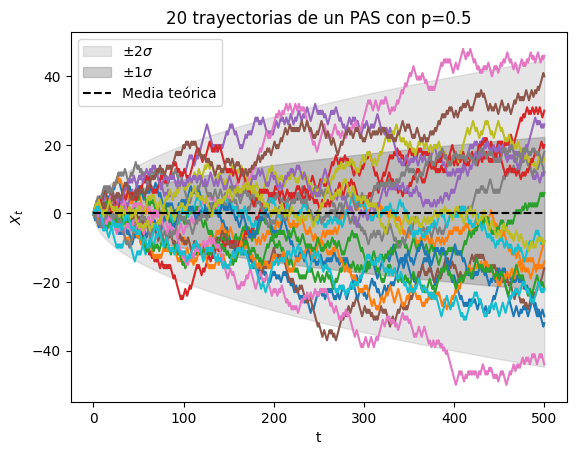

In [ ]:
p=0.5
n=500
reps=20
trayectoria=simular_PAS(p,n,reps)
pasos = np.arange(trayectoria.shape[1]) # La coordenada x para luego dibujar el sombreado y la media teórica.
media = pasos*(2*p-1) # La media teórica del PAS.
desv_tipica = np.sqrt(4*p*(1-p)*pasos) # La desviación típica teórica del PAS.

plt.fill_between(pasos, media - 2*desv_tipica, media + 2*desv_tipica, #Dibujo de 2 veces la desviación típica respecto de la media teórica
                 color='gray', alpha=0.2, label=r'$\pm 2\sigma$')
plt.fill_between(pasos, media - desv_tipica, media + desv_tipica, #Dibujo de 1 vez la desviación típica respecto de la media teórica
                 color='gray', alpha=0.4, label=r'$\pm 1\sigma$')

for i in range(trayectoria.shape[0]):
  plt.plot(trayectoria[i])

plt.plot(pasos, media, color='black', linestyle='--', label='Media teórica') #Dibujo media teórica.

plt.legend()
plt.xlabel("t")
plt.ylabel("$X_t$")
plt.title("20 trayectorias de un PAS con p=0.5");



Diapositiva 31:

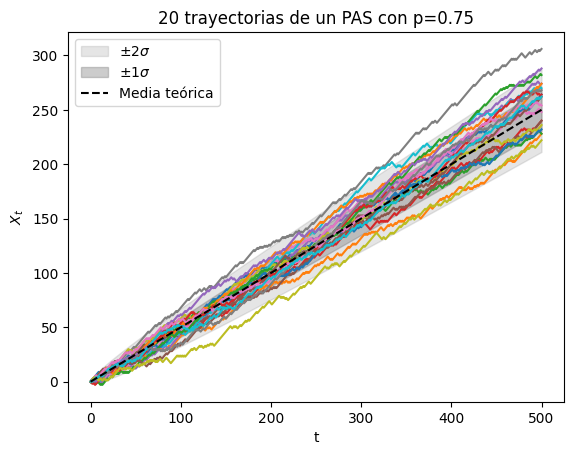

In [ ]:
p=0.75
n=500
reps=20
trayectoria=simular_PAS(p,n,reps)
pasos = np.arange(trayectoria.shape[1]) # La coordenada x para luego dibujar el sombreado y la media teórica.
media = pasos*(2*p-1) # La media teórica del PAS.
desv_tipica = np.sqrt(4*p*(1-p)*pasos) # La desviación típica teórica del PAS.

plt.fill_between(pasos, media - 2*desv_tipica, media + 2*desv_tipica, #Dibujo de 2 veces la desviación típica respecto de la media teórica
                 color='gray', alpha=0.2, label=r'$\pm 2\sigma$')
plt.fill_between(pasos, media - desv_tipica, media + desv_tipica, #Dibujo de 1 vez la desviación típica respecto de la media teórica
                 color='gray', alpha=0.4, label=r'$\pm 1\sigma$')

for i in range(trayectoria.shape[0]):
  plt.plot(trayectoria[i])

plt.plot(pasos, media, color='black', linestyle='--', label='Media teórica') #Dibujo media teórica.

plt.legend()
plt.xlabel("t")
plt.ylabel("$X_t$")
plt.title("20 trayectorias de un PAS con p=0.75");

Diapositiva 32:

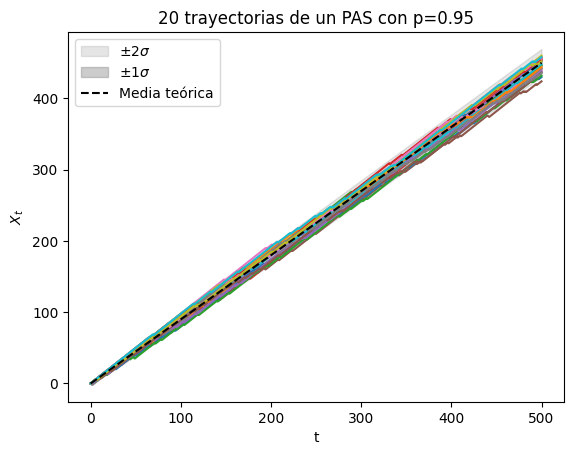

In [ ]:
p=0.95
n=500
reps=20
trayectoria=simular_PAS(p,n,reps)
pasos = np.arange(trayectoria.shape[1]) # La coordenada x para luego dibujar el sombreado y la media teórica.
media = pasos*(2*p-1) # La media teórica del PAS.
desv_tipica = np.sqrt(4*p*(1-p)*pasos) # La desviación típica teórica del PAS.

plt.fill_between(pasos, media - 2*desv_tipica, media + 2*desv_tipica, #Dibujo de 2 veces la desviación típica respecto de la media teórica
                 color='gray', alpha=0.2, label=r'$\pm 2\sigma$')
plt.fill_between(pasos, media - desv_tipica, media + desv_tipica, #Dibujo de 1 vez la desviación típica respecto de la media teórica
                 color='gray', alpha=0.4, label=r'$\pm 1\sigma$')

for i in range(trayectoria.shape[0]):
  plt.plot(trayectoria[i])

plt.plot(pasos, media, color='black', linestyle='--', label='Media teórica') #Dibujo media teórica.

plt.legend()
plt.xlabel("t")
plt.ylabel("$X_t$")
plt.title("20 trayectorias de un PAS con p=0.95");

# Visualización 3

Text(0, 0.5, '$X_t$')

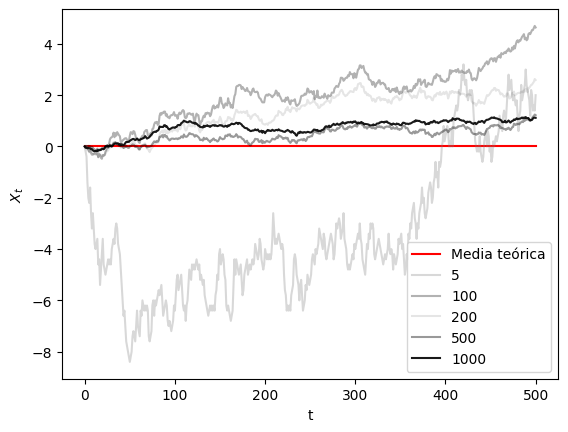

In [ ]:
p=0.5
n=500
reps=1000
trayectoria=simular_PAS(p,n,reps)
pasos = np.arange(n+1) # La coordenada x para luego dibujar el sombreado y la media teórica.
media = pasos*(2*p-1) # La media teórica del PAS.
plt.plot(pasos, media, color='red', label='Media teórica') #Dibujo media teórica.


media_5= np.mean(trayectoria[:5], axis=0)
media_100= np.mean(trayectoria[:100], axis=0)
media_200= np.mean(trayectoria[:200], axis=0)
media_500= np.mean(trayectoria[:500], axis=0)
media_1000= np.mean(trayectoria, axis=0)

plt.plot(pasos, media_5, label="5", color="gray", alpha=0.3)
plt.plot(pasos, media_100, label="100", color="gray", alpha=0.6)
plt.plot(pasos, media_200, label="200", color="black", alpha=0.1)
plt.plot(pasos, media_500, label="500", color="black", alpha=0.4)
plt.plot(pasos, media_1000, label="1000", color="black", alpha=0.9)

plt.legend()
plt.xlabel("t")
plt.ylabel("$X_t$")
